In [28]:
%pip install numpy pandas seaborn torch torchvision scikit-learn matplotlib graphviz tqdm

Note: you may need to restart the kernel to use updated packages.


In [29]:
import torch.nn as nn
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

In [30]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df["quality"] = (df["quality"] >= 6).astype(int)

# Split features and target
X = df.drop(columns=["quality"]).values
y = df["quality"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [31]:
class SLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SLP, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

In [37]:
def train(
    model, train_loader, criterion, optimizer, epochs=50, scheduler=None, lambda_lr=None
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_acc = 0
        train_loss = 0

        for X_batch, y_batch in tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"
        ):
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            if lambda_lr:
                l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
                loss = loss + lambda_lr * l2_norm

            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_acc += (predicted == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_dataset)
        avg_train_acc = train_acc / len(train_dataset)

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        model.eval()
        val_acc = 0
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(
                test_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"
            ):
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_acc += (predicted == y_batch).sum().item()

        avg_val_loss = val_loss / len(test_dataset)
        avg_val_acc = val_acc / len(test_dataset)
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}"
        )

    return train_losses, train_accuracies, val_losses, val_accuracies

In [38]:
from torch import optim


def get_optimizer_scheduler(optimizer_name, model_parameters, lr, scheduler_name=None):
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model_parameters, lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model_parameters, lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model_parameters, lr=lr, alpha=0.9)
    elif optimizer_name == "Adagrad":
        optimizer = optim.Adagrad(model_parameters, lr=lr)
    else:
        raise ValueError("Unsupported optimizer")

    scheduler = None
    if scheduler_name == "ExponentialLR":
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    elif scheduler_name == "StepLR":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    return optimizer, scheduler

In [39]:
model = SLP(input_dim=X_train_tensor.shape[1], output_dim=2)

criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.003995534862576165)
# optimizer = torch.optim.SGD(
#     model.parameters(), lr=9.633293015327061e-05, weight_decay=0.0001
# )
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 5
optimizer, scheduler = get_optimizer_scheduler(
    "Adam", model.parameters(), lr=0.001, scheduler_name=None
)

train_losses, train_accuracies, val_losses, val_accuracies = train(
    model, train_loader, criterion, optimizer, epochs=epochs, scheduler=scheduler
)

Epoch 1/5 - Validation: 100%|██████████| 10/10 [00:00<00:00, 5066.20it/s]


Epoch 1/5 - Train Loss: 0.0213, Train Acc: 0.5880, Val Loss: 0.0205, Val Acc: 0.6219


Epoch 2/5 - Validation: 100%|██████████| 10/10 [00:00<00:00, 2097.26it/s]


Epoch 2/5 - Train Loss: 0.0200, Train Acc: 0.6435, Val Loss: 0.0195, Val Acc: 0.6438


Epoch 3/5 - Validation: 100%|██████████| 10/10 [00:00<00:00, 241.91it/s]


Epoch 3/5 - Train Loss: 0.0191, Train Acc: 0.6810, Val Loss: 0.0188, Val Acc: 0.6687


Epoch 4/5 - Validation: 100%|██████████| 10/10 [00:00<00:00, 6147.30it/s]


Epoch 4/5 - Train Loss: 0.0185, Train Acc: 0.6919, Val Loss: 0.0182, Val Acc: 0.6781


Epoch 5/5 - Validation: 100%|██████████| 10/10 [00:00<00:00, 6328.16it/s]

Epoch 5/5 - Train Loss: 0.0180, Train Acc: 0.7029, Val Loss: 0.0178, Val Acc: 0.6969


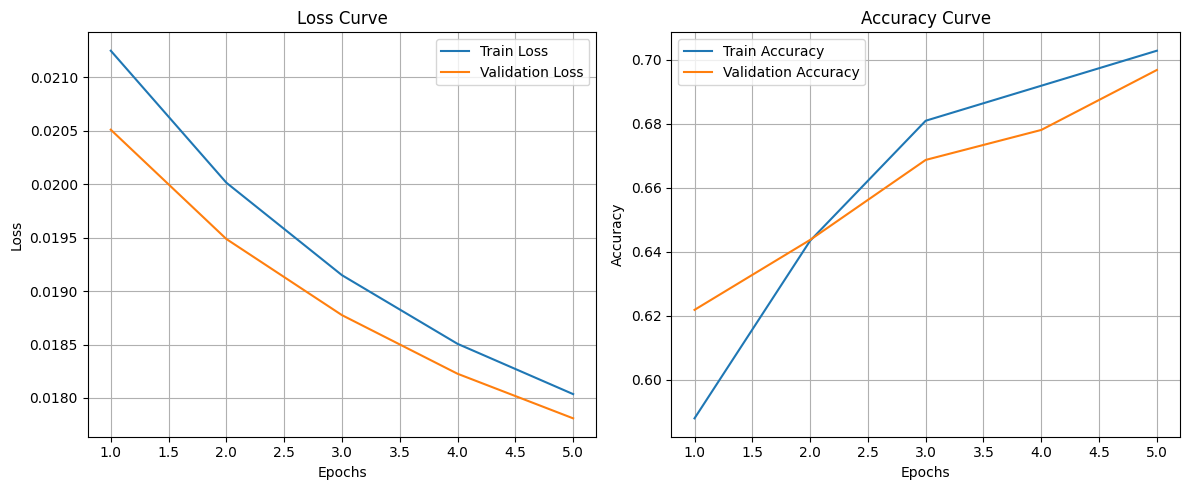

In [40]:
epochs_range = list(range(1, epochs + 1))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
axs[0].plot(epochs_range, train_losses, label="Train Loss")
axs[0].plot(epochs_range, val_losses, label="Validation Loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss Curve")
axs[0].legend()
axs[0].grid(True)

# Plot Accuracy
axs[1].plot(epochs_range, train_accuracies, label="Train Accuracy")
axs[1].plot(epochs_range, val_accuracies, label="Validation Accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy Curve")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


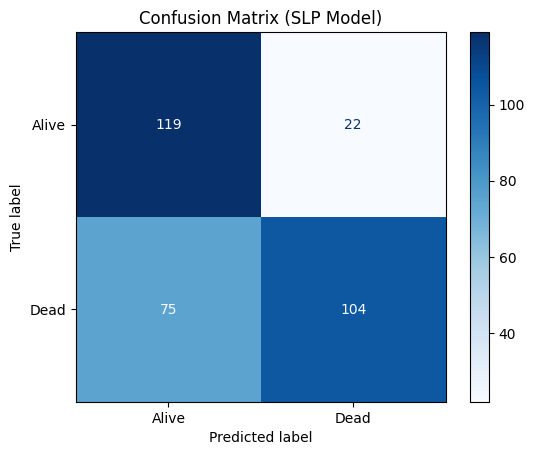

In [41]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Alive", "Dead"])
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix (SLP Model)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()
